# Football Tracking Ball Training Models

## Usage
1. Upload training and Validation Images in `datasets` folder
2. Run cells based on requiremet
3. Outputs appear in `/content/drive/MyDrive/yolo_runs/<project name>/weights/best.pt`

## Notes
- Requires frames collection with labelled bounding boxes

# Required

In [ ]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.2 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Optional
In case a datasets folder exists

In [ ]:
rm -r /content/datasets

rm: cannot remove '/content/datasets': No such file or directory


In [ ]:
!cp /content/drive/MyDrive/dataset.zip /content/


In [ ]:
!unzip /content/dataset.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/labels/train/BM_00766.txt  
  inflating: /content/dataset/labels/train/BM_00767.txt  
  inflating: /content/dataset/labels/train/BM_00768.txt  
  inflating: /content/dataset/labels/train/BM_00769.txt  
  inflating: /content/dataset/labels/train/BM_00771.txt  
  inflating: /content/dataset/labels/train/BM_00772.txt  
  inflating: /content/dataset/labels/train/BM_00773.txt  
  inflating: /content/dataset/labels/train/BM_00774.txt  
  inflating: /content/dataset/labels/train/BM_00775.txt  
  inflating: /content/dataset/labels/train/BM_00776.txt  
  inflating: /content/dataset/labels/train/BM_00777.txt  
  inflating: /content/dataset/labels/train/BM_00778.txt  
  inflating: /content/dataset/labels/train/BM_00779.txt  
  inflating: /content/dataset/labels/train/BM_00780.txt  
  inflating: /content/dataset/labels/train/BM_00781.txt  
  inflating: /content/dataset/labels/train/BM_00782.txt  
  inflating: /content

# Required

In [ ]:
yaml_content = """
path: /content/dataset
train: images/train
val: images/val

names:
  0: ball
"""

with open("/content/dataset/data.yaml", "w") as f:
    f.write(yaml_content)

# Optional
- check GPU Unit for best model fitting

In [1]:
!nvidia-smi
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

ERROR: Option gpu_info is not recognized. Please run 'nvidia-smi -h'.



NameError: name 'gpu_info' is not defined

# Required

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

model.train(
    data="/content/dataset/data.yaml",
    epochs=100, # change based on requirements
    imgsz=640, # change based on requirements
    batch=16, # change based on requirements
    project="/content/drive/MyDrive/yolo_runs",
    name="ball_detector_20260401", # change based on requirements
    save=True,
    save_period=1,
    save_txt=True,
    save_conf=True
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78f75c5da840>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

# Optional
- in case the model needs to improve

In [ ]:
import os

ckpt = "/content/drive/MyDrive/yolo_runs/1/weights/last.pt"
print("exists:", os.path.exists(ckpt))

exists: True


In [ ]:
from ultralytics import YOLO

model = YOLO(ckpt)
model.train(resume=True)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, in

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7959ac735fa0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

# Optiona
-Verify Results

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# load results
df = pd.read_csv("/content/drive/MyDrive/yolo_runs/ball_detector_20260401_1280_150epocs_1/results.csv") # change based on projected folder

# preview columns
print(df.columns)

Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2', 'lr/pg3', 'lr/pg4', 'lr/pg5', 'lr/pg6',
       'lr/pg7'],
      dtype='object')


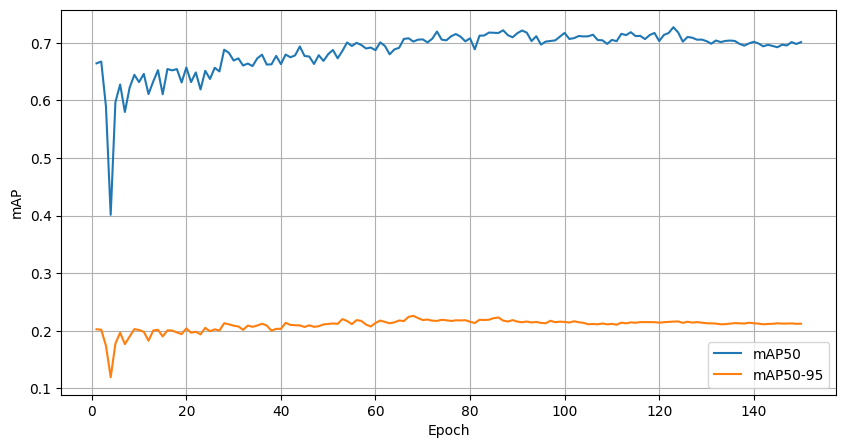

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50')
plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95')
plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.legend()
plt.grid()
plt.show()

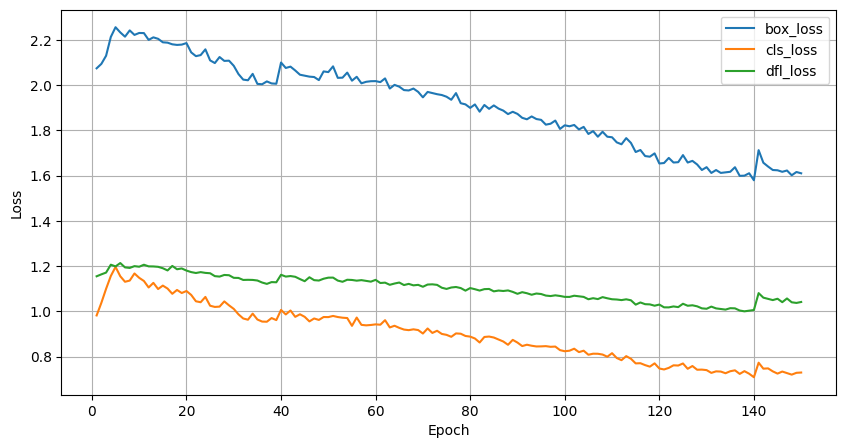

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df['epoch'], df['train/box_loss'], label='box_loss')
plt.plot(df['epoch'], df['train/cls_loss'], label='cls_loss')
plt.plot(df['epoch'], df['train/dfl_loss'], label='dfl_loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

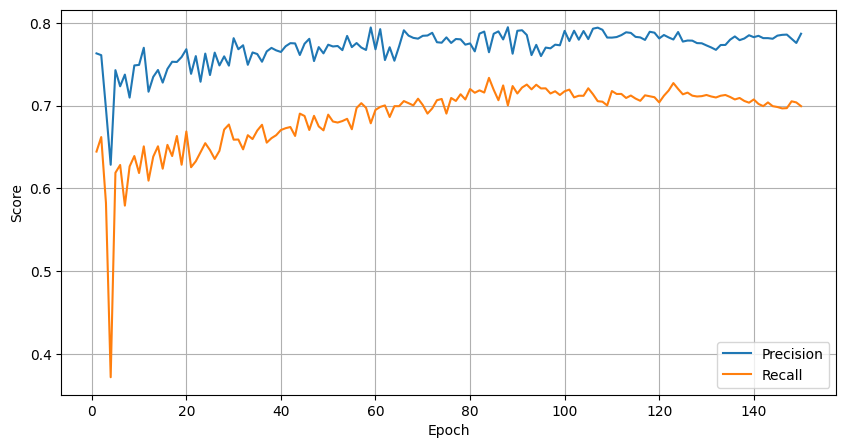

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df['epoch'], df['metrics/precision(B)'], label='Precision')
plt.plot(df['epoch'], df['metrics/recall(B)'], label='Recall')
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid()
plt.show()
